In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
from european_analytics import EuropeanAnalyticsSABR
from models import SABR

In [22]:
F0=0.05
T=1.0
beta=0.5
nu=0.2
rho=-0.3
sigma_atm=0.20
lambda_=0.04

# Simulation parameters
N_STEPS = 252
N_PATHS = 20_000
SEED    = 42

sabr = EuropeanAnalyticsSABR(F0, T, beta, nu, rho, sigma_atm, lambda_)

print(f"alpha(inverted using Hagan formula): {sabr.alpha:.6f}")
print(f"F_shifted: {sabr.F_s:.4f}")

# Simulation
sim = SABR(F0=F0, A0=sabr.alpha, rho=rho,T=T, n_steps=N_STEPS, n_paths=N_PATHS,beta=beta, nu=nu, seed=SEED)
F_paths, A_paths = sim.run()
print(f"Paths shape: {F_paths.shape}")

alpha(inverted using Hagan formula): 0.061330
F_shifted: 0.0900
Paths shape: (20000, 253)


In [16]:
F0=0.05
T=1.0
beta=0.5
nu=0.2
rho=-0.3
sigma_atm=0.20
lambda_=0.04

# Simulation parameters
N_STEPS = 252
N_PATHS = 20_000
SEED    = 42

dt = T / N_STEPS                          # uses T, n_steps
F = np.zeros((N_PATHS, N_STEPS + 1))      # uses n_paths, n_steps
A = np.zeros((N_PATHS, N_STEPS + 1))
F[:, 0] = F0                                   # uses F0
A[:, 0] = 0.061330

print(A)

[[0.06133 0.      0.      ... 0.      0.      0.     ]
 [0.06133 0.      0.      ... 0.      0.      0.     ]
 [0.06133 0.      0.      ... 0.      0.      0.     ]
 ...
 [0.06133 0.      0.      ... 0.      0.      0.     ]
 [0.06133 0.      0.      ... 0.      0.      0.     ]
 [0.06133 0.      0.      ... 0.      0.      0.     ]]


Terminal F(T) — mean: 0.04994  std: 0.01379  skew: 0.260  kurt: 0.218


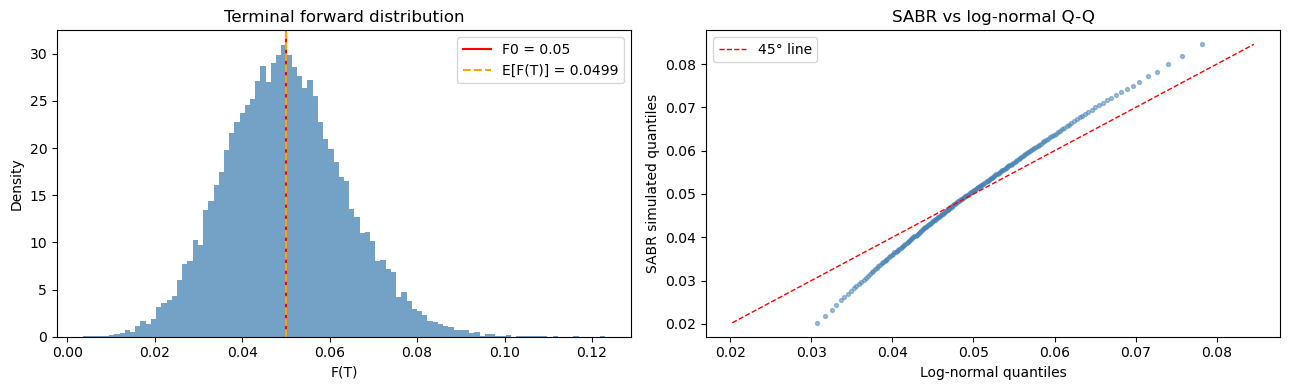

In [ ]:
F_T = F_paths[:, -1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of F(T)
axes[0].hist(F_T, bins=100, color='steelblue', alpha=0.75, density=True)
axes[0].axvline(F0, color='red', lw=1.5, label=f'F0 = {F0}')
axes[0].axvline(np.mean(F_T), color='orange', lw=1.5, linestyle='--',label=f'E[F(T)] = {np.mean(F_T):.4f}')
axes[0].set_xlabel('F(T)')
axes[0].set_ylabel('Density')
axes[0].set_title('Terminal forward distribution')
axes[0].legend()

# Q-Q style: compare to log-normal
q_sim  = np.percentile(F_T, np.linspace(1, 99, 200))
q_ln   = np.percentile(
    np.random.default_rng(0).lognormal(
        np.log(F0) - 0.5 * sigma_atm**2 * T,
        sigma_atm * np.sqrt(T), size=200_000
    ), np.linspace(1, 99, 200)
)
axes[1].scatter(q_ln, q_sim, s=8, alpha=0.5, color='steelblue')
mn, mx = min(q_ln.min(), q_sim.min()), max(q_ln.max(), q_sim.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', lw=1, label='45° line')
axes[1].set_xlabel('Log-normal quantiles')
axes[1].set_ylabel('SABR simulated quantiles')
axes[1].set_title('SABR vs log-normal Q-Q')
axes[1].legend()

stats = sim.compute_stats(F_paths)
print(f"Terminal F(T) — mean: {stats['mean'][-1]:.5f}  "
      f"std: {stats['std_dev'][-1]:.5f}  "
      f"skew: {stats['skewness'][-1]:.3f}  "
      f"kurt: {stats['kurtosis'][-1]:.3f}")
plt.tight_layout()
plt.show()

In [ ]:
# Time to expiry sweep
maturities = [0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
# For different colours in the plots
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(maturities)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
axes = axes.flatten()

for ax, T_i, col in zip(axes, maturities, colors):
    # Create SABR instance for each maturity
    sabr_i = EuropeanAnalyticsSABR(F0, T_i, beta, nu, rho, sigma_atm, lambda_)

    # Simulate SABR paths
    sim_i = SABR(
        F0=F0, A0=sabr_i.alpha, rho=rho,
        T=T_i, n_steps=max(int(252 * T_i), 50),
        n_paths=N_PATHS, beta=beta, nu=nu, seed=SEED
    )
    # Run the simulation
    F_i, _ = sim_i.run()

    # Strikes for volatility smile
    std_i = sigma_atm * F0 * np.sqrt(T_i)
    K_min_i = max(F0 - 2.5 * std_i, -lambda_ + 1e-4)
    K_max_i = F0 + 2.5 * std_i
    strikes_i = np.linspace(K_min_i, K_max_i, 30)

    # IV using Hagan's approximation
    v_hagan = sabr_i.implied_vol_smile(strikes_i)
    # IV using Black-Scholes inversion of MC terminal values
    v_mc    = sabr_i.implied_vol_smile(F_i, strikes_i)

    # Plots
    ax.plot(strikes_i * 100, v_hagan * 100, color=col, lw=2, label='Hagan')
    ax.plot(strikes_i * 100, v_mc * 100, 'o', color=col, ms=4, alpha=0.6, label='MC')
    ax.axvline(F0 * 100, color='gray', lw=1, ls='--')
    ax.set_title(f'T = {T_i}y')
    ax.set_xlabel('Strike (%)')
    ax.set_ylabel('Implied vol (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Smile divergence across maturities', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [2]:
sabr_test = EuropeanAnalyticsSABR(
    F0=0.05, T=1.0, beta=0.5, nu=0.4,
    rho=-0.3, sigma_atm=0.20, lambda_=0.0
)
print(f"ATM vol (no shift): {sabr_test.hagan_implied_vol(0.05)*100:.4f}%")

ATM vol (no shift): 21.3526%


In [3]:
sabr_test2 = EuropeanAnalyticsSABR(
    F0=0.05, T=1.0, beta=0.5, nu=0.2,
    rho=-0.3, sigma_atm=0.20, lambda_=0.04
)
print(f"ATM vol (nu=0.2): {sabr_test2.hagan_implied_vol(0.05)*100:.4f}%")

sabr_test3 = EuropeanAnalyticsSABR(
    F0=0.05, T=0.25, beta=0.5, nu=0.4,
    rho=-0.3, sigma_atm=0.20, lambda_=0.04
)
print(f"ATM vol (T=0.25): {sabr_test3.hagan_implied_vol(0.05)*100:.4f}%")

ATM vol (nu=0.2): 20.4797%
ATM vol (T=0.25): 20.2371%


In [4]:
# Check what alpha the cubic produces
print(f"alpha             : {sabr.alpha:.6f}")

# Manually evaluate the cubic at the solved alpha — should be ~0
Fb = sabr.F_s**(1 - sabr.beta)
c3 = (1 - sabr.beta)**2 * sabr.T / (24 * Fb**2)
c1 = 1 + ((2 - 3*sabr.rho**2)/24 * sabr.nu**2 * sabr.T) + sabr.rho*sabr.beta*sabr.nu*sabr.T / (4*Fb)
c0 = -sabr.sigma_atm * Fb

alpha = sabr.alpha
print(f"cubic at alpha    : {c3*alpha**3 + c1*alpha + c0:.2e}")  # should be ~0

# Now manually compute ATM vol from hagan formula
correction = (1-sabr.beta)**2 * alpha**2 / (24 * Fb**2) + sabr.rho*sabr.beta*sabr.nu*alpha / (4*Fb) + (2 - 3*sabr.rho**2)/24 * sabr.nu**2
sigma_B = (alpha / Fb) * (1 + correction * sabr.T)
print(f"manual ATM vol    : {sigma_B*100:.4f}%")
print(f"target sigma_atm  : {sabr.sigma_atm*100:.4f}%")

alpha             : 0.062371
cubic at alpha    : 6.94e-18
manual ATM vol    : 20.9747%
target sigma_atm  : 20.0000%


In [5]:
print(f"Fb  : {Fb:.6f}")
print(f"c3  : {c3:.6f}")
print(f"c1  : {c1:.6f}")
print(f"c0  : {c0:.6f}")

# What c1 should produce if round-trip were perfect:
# sigma_atm * Fb / alpha - c3 * alpha^2 should equal c1
print(f"check: {sabr.sigma_atm * Fb / alpha - c3 * alpha**2:.6f}")

Fb  : 0.300000
c3  : 0.115741
c1  : 0.961533
c0  : -0.060000
check: 0.961533


In [6]:
print(f"F0        : {sabr.F0}")
print(f"F_s       : {sabr.F_s}")
print(f"T         : {sabr.T}")
print(f"beta      : {sabr.beta}")
print(f"nu        : {sabr.nu}")
print(f"rho       : {sabr.rho}")
print(f"sigma_atm : {sabr.sigma_atm}")
print(f"lambda_   : {sabr.lambda_}")
print(f"alpha     : {sabr.alpha:.6f}")

F0        : 0.05
F_s       : 0.09
T         : 1.0
beta      : 0.5
nu        : 0.4
rho       : -0.3
sigma_atm : 0.2
lambda_   : 0.04
alpha     : 0.062371
